<a href="https://colab.research.google.com/github/financial1A/ML/blob/main/NDXvPREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_628/335323904.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(list(ticker_map.values()), period="1mo", interval="1h")['Close']
[*******               14%                       ]  2 of 14 completed

[*********************100%***********************]  14 of 14 completed
/tmp/ipykernel_628/335323904.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = raw_data.fillna(method='ffill').dropna()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training on 14 features...
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0544
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0072
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0052
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0049
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0045
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0042
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0033
Epoch 9/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0039
Epoch 10/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0034
Epoch 11/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0034
Epoch 12/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0033
Epoch 13/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0032
Epoch 14/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0031
Epoch 15/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11

/tmp/ipykernel_628/335323904.py:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_row[TARGET_IDX] = pred


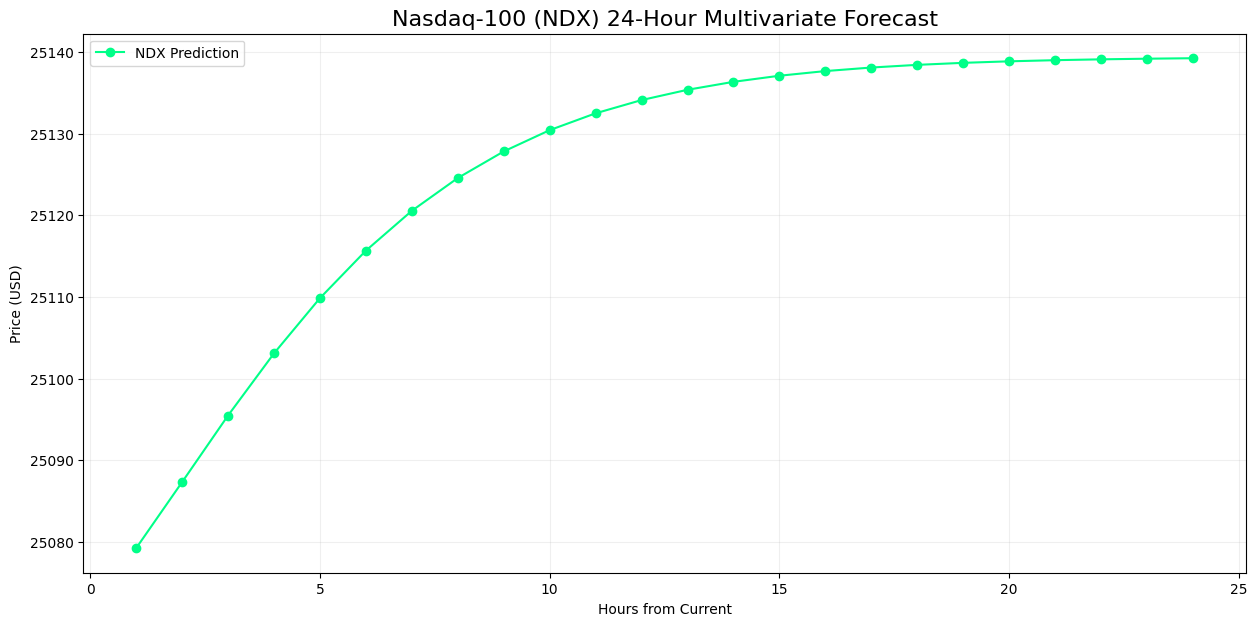

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from datetime import datetime, timedelta

# --- 1. MAPPING YOUR TICKERS ---
# Mapping the labels from your screenshot to yfinance symbols
ticker_map = {
    'NDX': '^NDX',      # Nasdaq 100 (Target)
    'DXY': 'DX-Y.NYB',  # US Dollar Index
    'VIX': '^VIX',      # Volatility Index
    'US02Y': '^IRX',    # 13 Week Treasury (Proxy for short term)
    'US10Y': '^TNX',    # 10 Year Treasury Yield
    'US30Y': '^TYX',    # 30 Year Treasury Yield
    'CL1!': 'CL=F',     # Crude Oil Futures
    'GDAXI': '^GDAXI',  # DAX Performance Index
    'FCHI': '^FCHI',    # CAC 40
    'NIKKEI': '^N225',  # Nikkei 225
    'ASX': '^AXJO',     # ASX 200
    'QQQ': 'QQQ',       # QQQ ETF
    'SPX': '^GSPC',     # S&P 500
    'BTCUSD': 'BTC-USD' # Bitcoin
}

print("Downloading hourly data for all tickers...")
# We use '1mo' period for 1h interval data
raw_data = yf.download(list(ticker_map.values()), period="1mo", interval="1h")['Close']

# Drop any rows with missing values (common due to different market holidays)
df = raw_data.fillna(method='ffill').dropna()

# Rearrange columns so NDX is at index 0 (the Target)
cols = ['^NDX'] + [c for c in df.columns if c != '^NDX']
df = df[cols]

# --- 2. PREPROCESSING ---
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

SEQ_LENGTH = 60 # Look back 60 hours
TARGET_IDX = 0  # NDX is the first column

def create_multivariate_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length, :]) # All features
        y.append(data[i + seq_length, TARGET_IDX]) # Only NDX Close
    return np.array(x), np.array(y)

X, y = create_multivariate_sequences(scaled_data, SEQ_LENGTH)

# --- 3. BUILD MODEL ---
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# --- 4. TRAINING ---
print(f"Training on {df.shape[1]} features...")
model.fit(X, y, batch_size=32, epochs=30, verbose=1)

# --- 5. RECURSIVE 24-HOUR PREDICTION ---
# Note: For simplicity, other features (VIX, DXY) are assumed to stay at
# their last known value during the 24h recursive NDX prediction.
last_window = scaled_data[-SEQ_LENGTH:]
future_ndx_scaled = []
current_batch = last_window.reshape((1, SEQ_LENGTH, df.shape[1]))

for i in range(24):
    pred = model.predict(current_batch, verbose=0)[0]
    future_ndx_scaled.append(pred)

    # Construct next row for batch: [Pred_NDX, Last_DXY, Last_VIX, ...]
    next_row = current_batch[0, -1, :].copy()
    next_row[TARGET_IDX] = pred

    # Slide window
    current_batch = np.append(current_batch[:, 1:, :], [[next_row]], axis=1)

# Inverse transform only the NDX predictions
# We create a dummy matrix to satisfy the scaler's shape requirement
dummy = np.zeros((24, df.shape[1]))
dummy[:, TARGET_IDX] = np.array(future_ndx_scaled).flatten()
forecast_prices = scaler.inverse_transform(dummy)[:, TARGET_IDX]

# --- 6. CHARTING ---
plt.figure(figsize=(15, 7))
plt.plot(range(1, 25), forecast_prices, color='#00ff88', marker='o', label='NDX Prediction')
plt.title('Nasdaq-100 (NDX) 24-Hour Multivariate Forecast', fontsize=16)
plt.ylabel('Price (USD)')
plt.xlabel('Hours from Current')
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()